# Dispersion Curve Validation Demo — ROMY M6.8 (2023-09-08)

This notebook mirrors `tests/test_core/test_dispersion.py` and adds plots to verify that
`compute_dispersion_curve` is implemented correctly on **real event data**.

**Event:** M6.8 earthquake on 2023-09-08, recorded at ROMY (Munich ring laser).

**Focus:** adaptive time-window length per frequency band and 50% overlap between consecutive windows.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from obspy import UTCDateTime

from sixdegrees.sixdegrees import sixdegrees
from sixdegrees.plots.plot_dispersion_curves import plot_dispersion_curves
from sixdegrees.plots.plot_dispersion_traces import plot_dispersion_traces
from cmcrameri import cm as cmcrameri_cm

plt.rcParams.update({"figure.figsize": (12, 4), "font.size": 11})

## Event configuration (2023-09-08 M6.8 @ ROMY)

In [ ]:
# Same event as examples/XROMY_analysis_demo1.ipynb and config/config_ROMY_M6.8_20230908.yml
config = {
    "tbeg": "2023-09-08 22:13:00",
    "tend": "2023-09-08 23:00:00",
    "origin_time": "2023-09-08 22:11:00",
    "magnitude": 6.8,
    "station_lon": 11.275476,
    "station_lat": 48.162941,
    "seed": "XX.ROMY..",
    "rot_seed": ["XX.ROMY..BJZ", "XX.ROMY..BJN", "XX.ROMY..BJE"],
    "tra_seed": ["XX.ROMY..BHZ", "XX.ROMY..BHN", "XX.ROMY..BHE"],
    "data_source": "mseed_file",
    "path_to_mseed_file": "./data/romy_eventM6.8.mseed",
    "workdir": "./",
    "path_to_data_out": "./output/",
    "project": "ROMY_Analysis",
    "fmin": 0.02,
    "fmax": 0.2,
    "verbose": True,
}


In [73]:
# Dispersion-processing parameters (window geometry checks from unit tests)
OCTAVE_FRACTION = 6
WINDOW_FACTOR = 6.0       # T = max(window_factor / f_center, 1 s)
TIME_WINDOW_OVERLAP = 0.75 # 50% overlap
CC_THRESHOLD = 0.8
BAZ_STEP = 1              # coarser step for faster demo run
FMIN, FMAX = 0.02, 0.2   # subset for validation plots (within config fmin/fmax)

## Helper functions for window geometry

In [74]:
def expected_window_count(n_samples, sampling_rate, time_window_sec, overlap):
    win_samples = int(time_window_sec * sampling_rate)
    overlap_samples = int(win_samples * overlap)
    step = win_samples - overlap_samples
    return int((n_samples - win_samples) / step) + 1


def expected_window_times(n_samples, sampling_rate, time_window_sec, overlap):
    win_samples = int(time_window_sec * sampling_rate)
    overlap_samples = int(win_samples * overlap)
    step = win_samples - overlap_samples
    n_windows = expected_window_count(n_samples, sampling_rate, time_window_sec, overlap)
    return np.array([(i * step + win_samples / 2) / sampling_rate for i in range(n_windows)])


def window_intervals(n_samples, sampling_rate, time_window_sec, overlap):
    """Return list of (t_start, t_end, t_center) for each sliding window."""
    win_samples = int(time_window_sec * sampling_rate)
    overlap_samples = int(win_samples * overlap)
    step = win_samples - overlap_samples
    n_windows = expected_window_count(n_samples, sampling_rate, time_window_sec, overlap)
    out = []
    for i in range(n_windows):
        i1 = i * step
        i2 = i1 + win_samples
        out.append((i1 / sampling_rate, i2 / sampling_rate, (i1 + win_samples / 2) / sampling_rate))
    return out

## 1. Load ROMY 6-DoF data and `sixdegrees` object

Data are read from the bundled MSEED file (`examples/data/romy_eventM6.8.mseed`), resampled to 5 Hz,
and trimmed to the analysis window (same workflow as `XROMY_analysis_demo1.ipynb`).

In [75]:
sd = sixdegrees(conf=config)

event_info = sd.get_event_info(
    origin_time=config["origin_time"],
    time_margin=60.0,
    base_catalog="ISC",
    magnitude=config["magnitude"],
)
sd.baz_theo = event_info["backazimuth"]

sd.load_data(config["tbeg"], config["tend"], resample_rate=5)
sd.trim(UTCDateTime(config["tbeg"]) + 100, UTCDateTime(config["tend"]) - 1000)

SR = sd.sampling_rate
tr = sd.st.select(channel="*JZ")[0]
duration = (tr.stats.endtime - tr.stats.starttime)

print(f"Event: M{config['magnitude']} on {config['origin_time']}")
print(f"Theoretical backazimuth: {sd.baz_theo:.1f}°")
print(f"Data: {duration:.0f} s @ {SR:.1f} Hz | {tr.stats.starttime} – {tr.stats.endtime}")

Found event:
Origin time: 2023-09-08T22:11:00.980000Z
Magnitude: 6.47 mb
Location: 31.046°N, -8.461°E
Depth: 18.5 km
Epicentral Distance: 2531.38 km
Epicentral Distance: 22.8°
Backazimuth: 228.52°
-> fetching XX.ROMY..BHZ data from mseed file
-> fetching XX.ROMY..BHN data from mseed file
-> fetching XX.ROMY..BHE data from mseed file
3 Trace(s) in Stream:
XX.ROMY..BHZ | 2023-09-08T22:12:58.989999Z - 2023-09-08T23:00:00.989999Z | 20.0 Hz, 56441 samples
XX.ROMY..BHN | 2023-09-08T22:12:58.990000Z - 2023-09-08T23:00:00.990000Z | 20.0 Hz, 56441 samples
XX.ROMY..BHE | 2023-09-08T22:12:58.990000Z - 2023-09-08T23:00:00.990000Z | 20.0 Hz, 56441 samples
-> fetching XX.ROMY..BJZ data from mseed file
-> fetching XX.ROMY..BJN data from mseed file
-> fetching XX.ROMY..BJE data from mseed file
3 Trace(s) in Stream:
XX.ROMY..BJZ | 2023-09-08T22:12:59.011600Z - 2023-09-08T23:00:01.011600Z | 20.0 Hz, 56441 samples
XX.ROMY..BJN | 2023-09-08T22:12:58.999400Z - 2023-09-08T23:00:00.999400Z | 20.0 Hz, 56441 s

## 2. Run `compute_dispersion_curve`

In [ ]:
results = sd.compute_dispersion_curve(
    wave_type="love",
    fmin=FMIN,
    fmax=FMAX,
    octave_fraction=OCTAVE_FRACTION,
    window_factor=WINDOW_FACTOR,
    time_window_overlap=TIME_WINDOW_OVERLAP,
    use_theoretical_baz=False,
    cc_threshold=CC_THRESHOLD,
    cc_method="mid",
    zero_intercept=False,
    baz_step=BAZ_STEP,
    verbose=True,
    velocity_threshold=5000.0,  # exclude v > 5000 m/s from KDE only
    n_jobs=2,
)

bands = results["frequency_bands"]
print(f"Computed {len(bands)} frequency bands")

TypeError: sixdegrees.compute_dispersion_curve() got an unexpected keyword argument 'velocity_threshold'

## 3. Tabular check: adaptive window length and array sizes

In [86]:
rows = []
for i, band in enumerate(bands):
    n_samples = len(band["filtered_rot"][0].data)
    tw = band["time_window"]
    expected_tw = max(WINDOW_FACTOR / band["f_center"], 1.0)
    expected_n = expected_window_count(n_samples, SR, tw, TIME_WINDOW_OVERLAP)
    rows.append({
        "band": i + 1,
        "f_center_Hz": band["f_center"],
        "f_range_Hz": f"{band['f_lower']:.3f}-{band['f_upper']:.3f}",
        "T_window_s": tw,
        "T_expected_s": expected_tw,
        "T_ok": np.isclose(tw, expected_tw),
        "n_windows": len(band["times"]),
        "n_expected": expected_n,
        "n_ok": len(band["times"]) == expected_n,
        "v_kde_m_s": band["kde_peak_velocity"],
        "baz_median_deg": np.nanmedian(band["backazimuths"]),
    })

summary = pd.DataFrame(rows)
print(summary.round({"f_center_Hz": 3, "T_window_s": 2, "T_expected_s": 2, "v_kde_m_s": 0, "baz_median_deg": 1}).to_string(index=False))

print("All T_window checks:", summary["T_ok"].all())
print("All window-count checks:", summary["n_ok"].all())

 band  f_center_Hz  f_range_Hz  T_window_s  T_expected_s  T_ok  n_windows  n_expected  n_ok  v_kde_m_s  baz_median_deg
    1        0.021 0.020-0.022      283.89        283.89  True         21          21  True       2900           221.0
    2        0.024 0.022-0.025      253.02        253.02  True         24          24  True       2900           230.5
    3        0.027 0.025-0.028      225.50        225.50  True         27          27  True       2900           240.0
    4        0.030 0.028-0.032      200.98        200.98  True         31          31  True       3100           193.0
    5        0.033 0.032-0.035      179.12        179.12  True         35          35  True       4200           184.0
    6        0.038 0.035-0.040      159.64        159.64  True         40          40  True       2900           262.0
    7        0.042 0.040-0.045      142.28        142.28  True         45          45  True       2200           237.0
    8        0.047 0.045-0.050      126.81      

## 4. Adaptive window length vs center frequency

For `window_factor = 1`, the window length is `T = max(1/f_center, 1 s)` — longer windows at low frequency, shorter at high frequency.

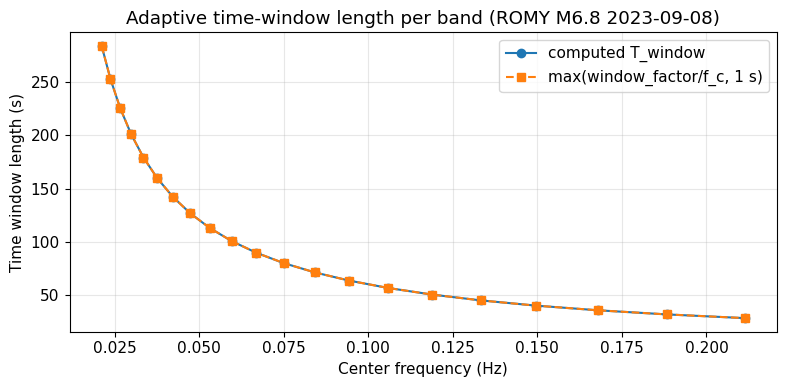

In [87]:
fig, ax = plt.subplots(figsize=(8, 4))
fc = summary["f_center_Hz"].values
T = summary["T_window_s"].values
T_theory = np.maximum(WINDOW_FACTOR / fc, 1.0)

ax.plot(fc, T, "o-", color="tab:blue", label="computed T_window")
ax.plot(fc, T_theory, "s--", color="tab:orange", label="max(window_factor/f_c, 1 s)")
ax.set_xlabel("Center frequency (Hz)")
ax.set_ylabel("Time window length (s)")
ax.set_title("Adaptive time-window length per band (ROMY M6.8 2023-09-08)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Time windows with overlap (key validation plot)

For each selected band we draw:
- **coloured spans** = analysis windows (note 50% overlap)
- **black ticks** = window centres stored in `band['times']`
- **red markers** = expected window centres from the sliding-window formula
- **grey trace** = filtered rotation (Love Z)

Zoom panels show the overlap clearly.

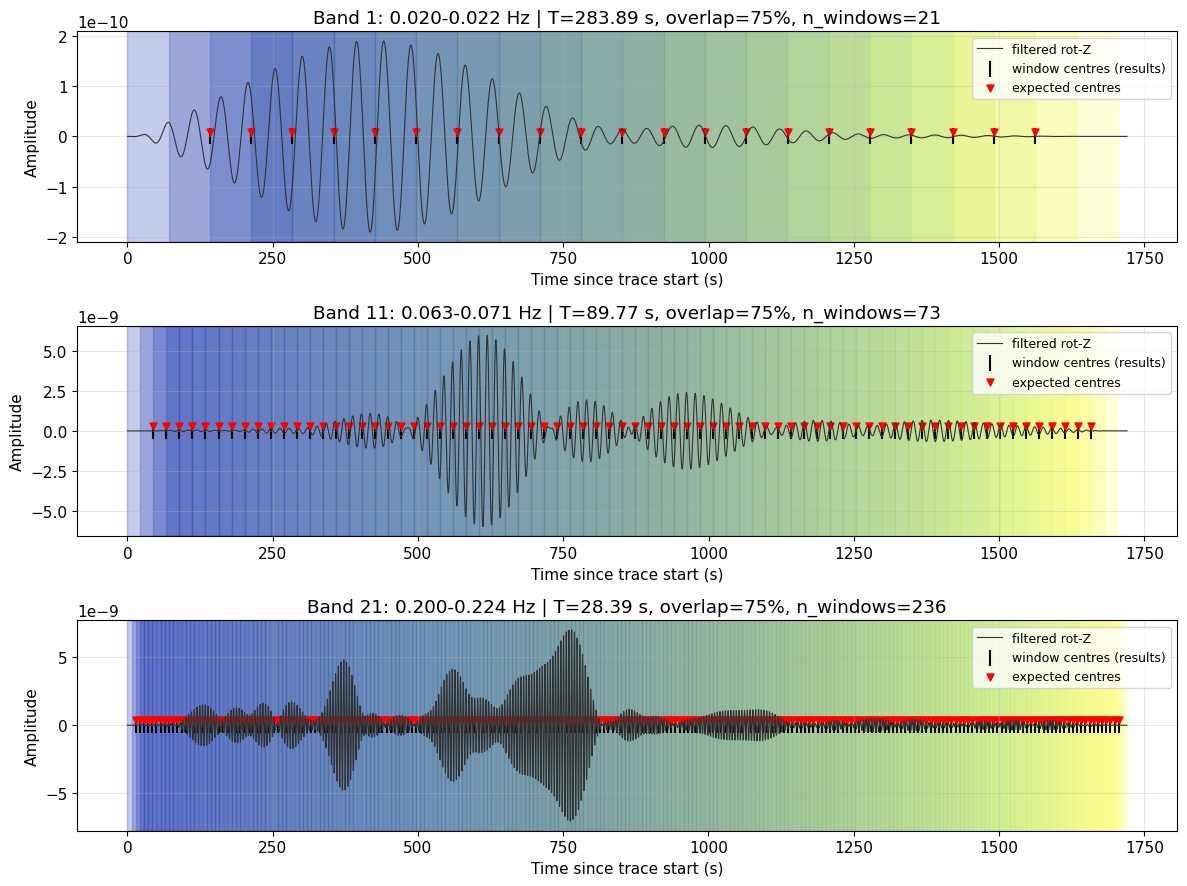

In [88]:
def plot_band_windows(band, band_idx, tmin=None, tmax=None, ax=None):
    rot = band["filtered_rot"].select(channel="*Z")[0]
    times_trace = rot.times()
    data = rot.data

    tw = band["time_window"]
    n_samples = len(data)
    intervals = window_intervals(n_samples, SR, tw, TIME_WINDOW_OVERLAP)
    expected_centers = expected_window_times(n_samples, SR, tw, TIME_WINDOW_OVERLAP)

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 3))

    cmap = cmcrameri_cm.imola
    for j, (t0, t1, tc) in enumerate(intervals):
        ax.axvspan(t0, t1, color=cmap(j / max(len(intervals) - 1, 1)), alpha=0.25)

    ax.plot(times_trace, data, color="0.2", lw=0.8, label="filtered rot-Z")
    ax.scatter(band["times"], np.zeros_like(band["times"]), marker="|", s=120, c="k", label="window centres (results)")
    ax.scatter(expected_centers, np.full_like(expected_centers, data.max() * 0.05), marker="v", s=25, c="red", label="expected centres")

    if tmin is not None or tmax is not None:
        ax.set_xlim(tmin if tmin is not None else times_trace[0], tmax if tmax is not None else times_trace[-1])

    ax.set_xlabel("Time since trace start (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(
        f"Band {band_idx+1}: {band['f_lower']:.3f}-{band['f_upper']:.3f} Hz | "
        f"T={tw:.2f} s, overlap={TIME_WINDOW_OVERLAP:.0%}, n_windows={len(intervals)}"
    )
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)
    return ax

pick = [0, len(bands)//2, len(bands)-1]
fig, axes = plt.subplots(len(pick), 1, figsize=(12, 3*len(pick)), sharex=False)
if len(pick) == 1:
    axes = [axes]
for ax, bi in zip(axes, pick):
    plot_band_windows(bands[bi], bi, ax=ax)
plt.tight_layout()
plt.show()

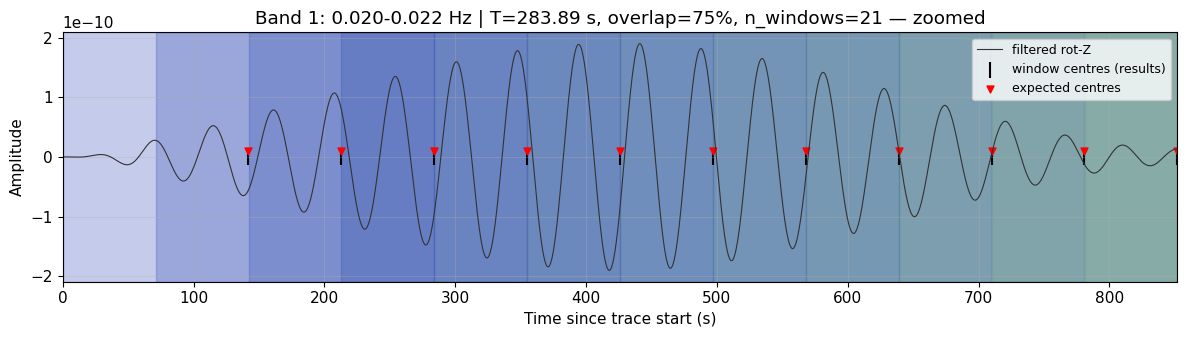

Lowest band: window = 283.89 s (1419 samples)
Step between window starts = 71.00 s  →  overlap = 75%


In [89]:
# Zoom lowest-frequency band: longest windows, overlap easiest to see
low_band = bands[0]
zoom_end = min(3 * low_band["time_window"], low_band["filtered_rot"][0].times()[-1])

fig, ax = plt.subplots(figsize=(12, 3.5))
plot_band_windows(low_band, 0, tmax=zoom_end, ax=ax)
ax.set_title(ax.get_title() + " — zoomed")
plt.tight_layout()
plt.show()

win_samples = int(low_band["time_window"] * SR)
step = win_samples - int(win_samples * TIME_WINDOW_OVERLAP)
print(f"Lowest band: window = {low_band['time_window']:.2f} s ({win_samples} samples)")
print(f"Step between window starts = {step/SR:.2f} s  →  overlap = {TIME_WINDOW_OVERLAP:.0%}")

## 6. Window centres match theory exactly

Band 1: max |Δt| = 0.00e+00 s
Band 11: max |Δt| = 0.00e+00 s
Band 21: max |Δt| = 0.00e+00 s


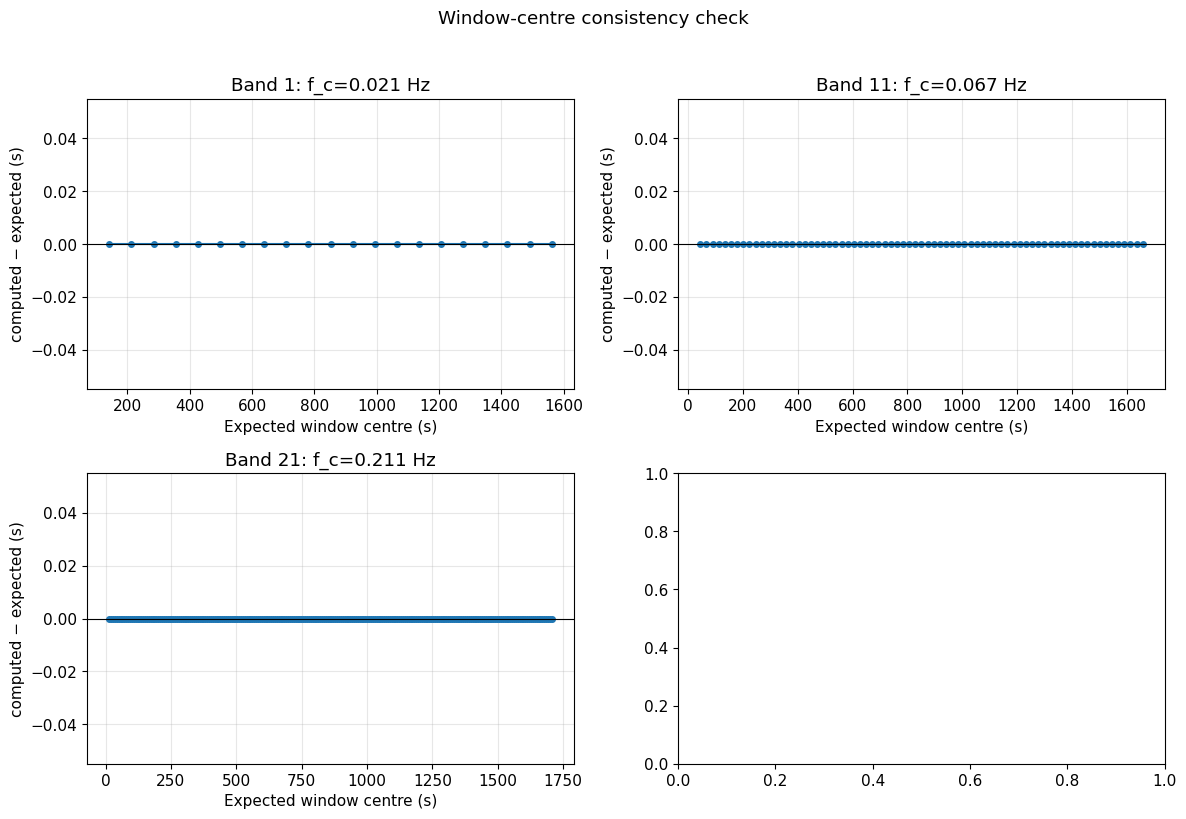

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, bi in zip(axes, pick):
    band = bands[bi]
    n_samples = len(band["filtered_rot"][0].data)
    tw = band["time_window"]
    expected = expected_window_times(n_samples, SR, tw, TIME_WINDOW_OVERLAP)
    diff = band["times"] - expected

    ax.plot(expected, diff, "o-", ms=4)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("Expected window centre (s)")
    ax.set_ylabel("computed − expected (s)")
    ax.set_title(f"Band {bi+1}: f_c={band['f_center']:.3f} Hz")
    ax.grid(True, alpha=0.3)
    print(f"Band {bi+1}: max |Δt| = {np.max(np.abs(diff)):.2e} s")

plt.suptitle("Window-centre consistency check", y=1.02)
plt.tight_layout()
plt.show()

## 7. Per-window velocities along time

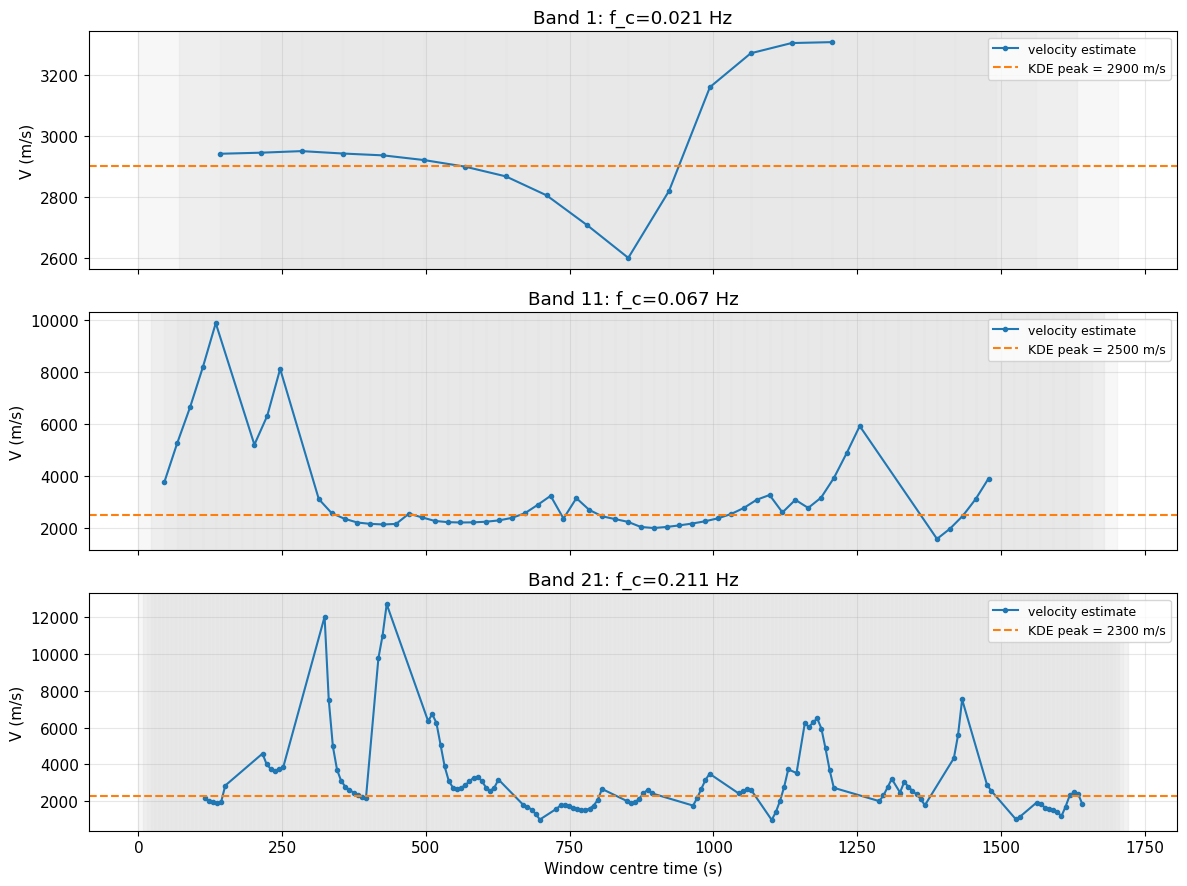

In [91]:
fig, axes = plt.subplots(len(pick), 1, figsize=(12, 3*len(pick)), sharex=True)
if len(pick) == 1:
    axes = [axes]

for ax, bi in zip(axes, pick):
    band = bands[bi]
    tw = band["time_window"]
    intervals = window_intervals(len(band["filtered_rot"][0].data), SR, tw, TIME_WINDOW_OVERLAP)

    for j, (t0, t1, _) in enumerate(intervals):
        ax.axvspan(t0, t1, color="0.9", alpha=0.5 if j % 2 else 0.3)

    v = band["velocities"]
    t = band["times"]
    valid = ~np.isnan(v)
    ax.plot(t[valid], v[valid], "o-", color="tab:blue", ms=3, label="velocity estimate")
    if not np.isnan(band["kde_peak_velocity"]):
        ax.axhline(band["kde_peak_velocity"], color="tab:orange", ls="--", lw=1.5,
                   label=f"KDE peak = {band['kde_peak_velocity']:.0f} m/s")
    ax.set_ylabel("V (m/s)")
    ax.set_title(f"Band {bi+1}: f_c={band['f_center']:.3f} Hz")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Window centre time (s)")
plt.tight_layout()
plt.show()

## 8. Package plot functions

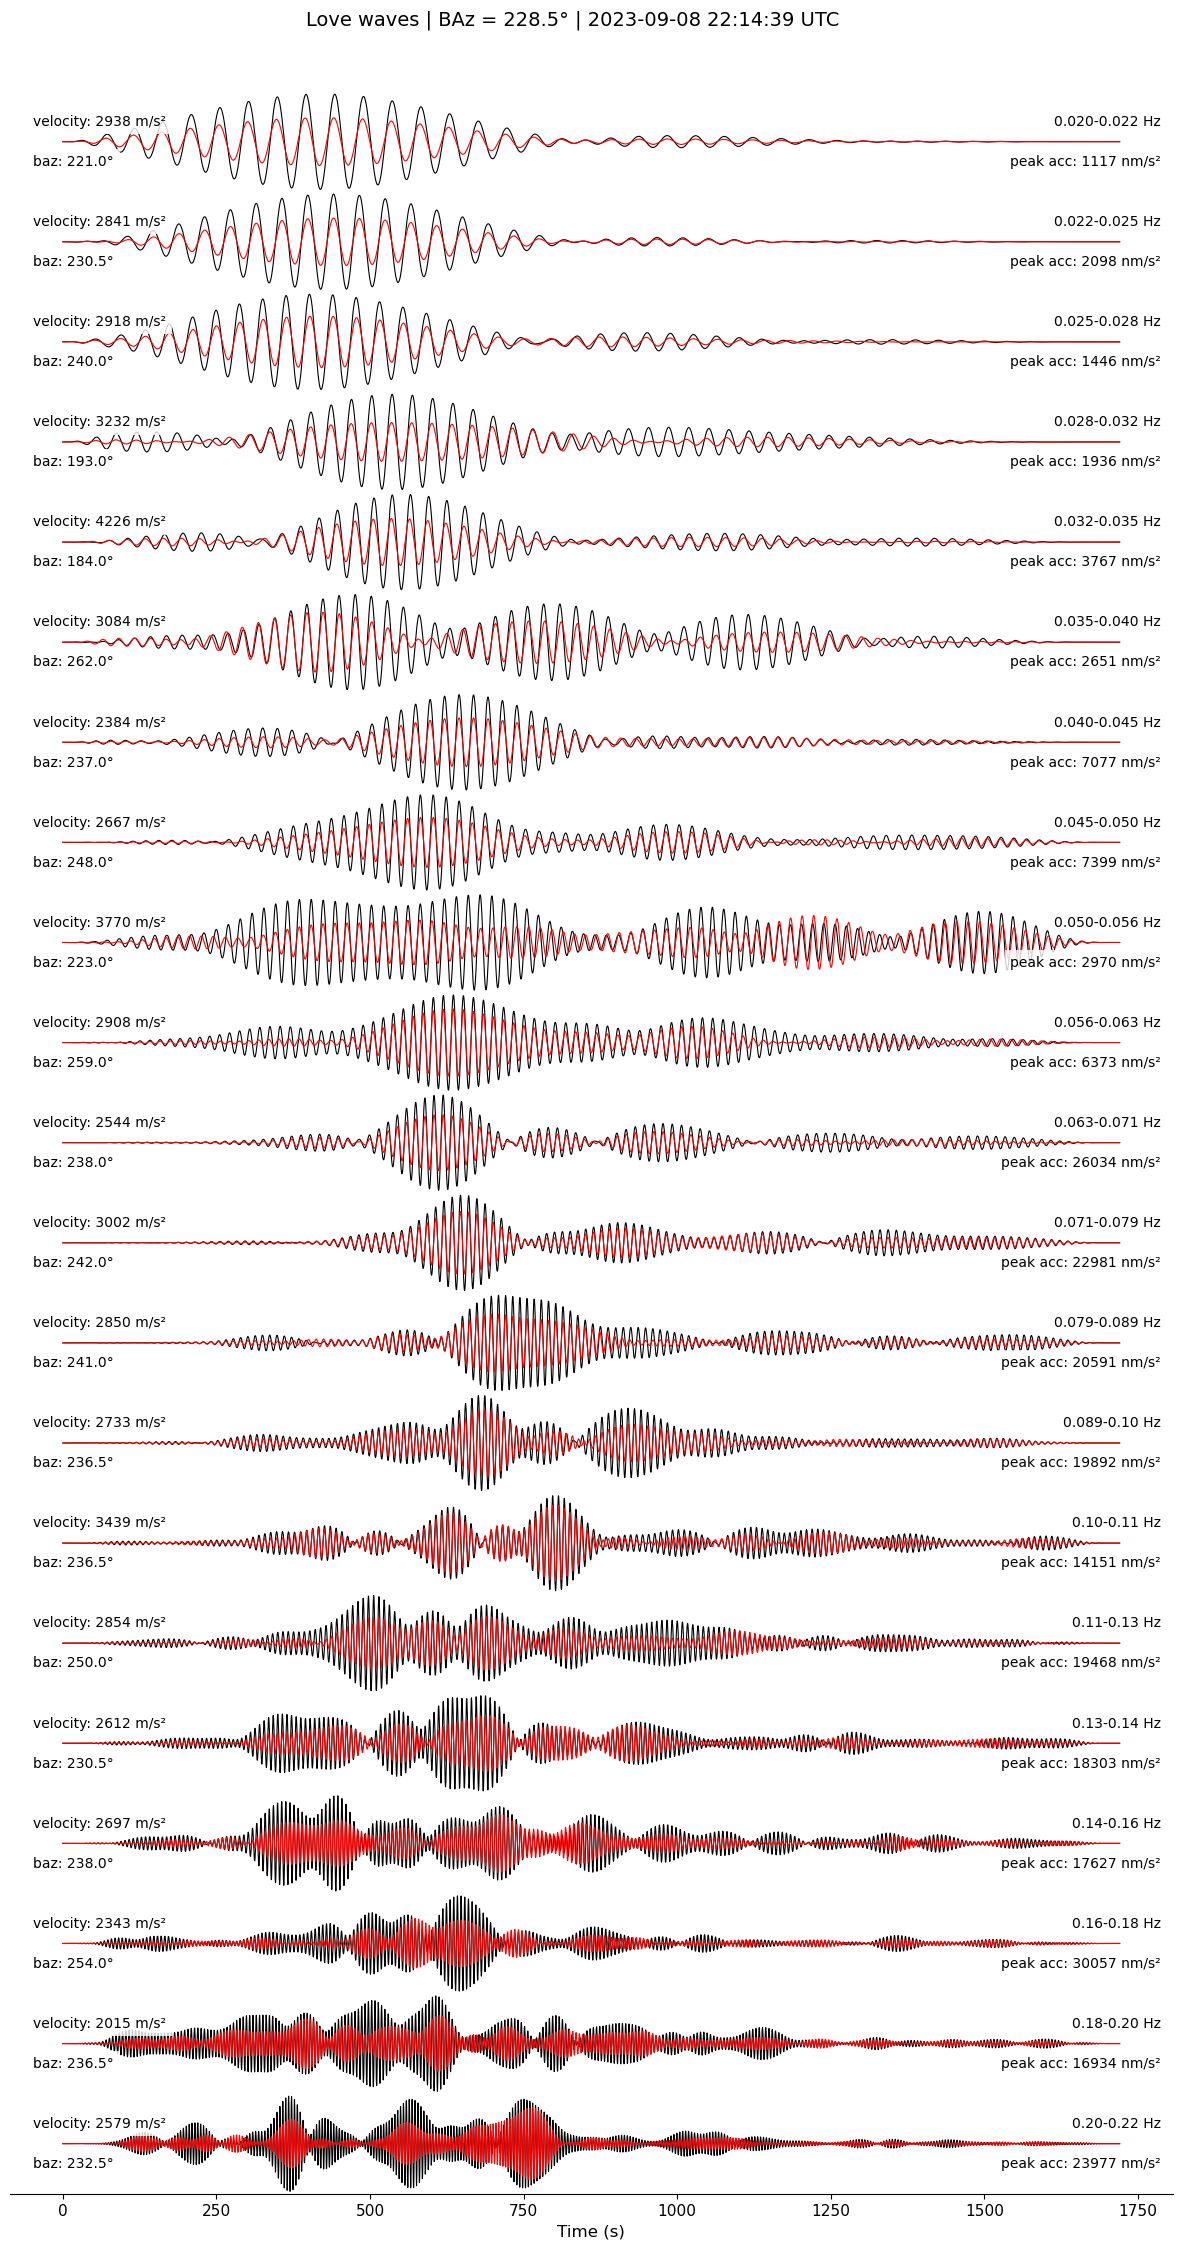

In [92]:
fig_traces = plot_dispersion_traces(
    results,
    data_type="acceleration",
    unitscale="nano",
    baz_theoretical=sd.baz_theo,
)
plt.show()

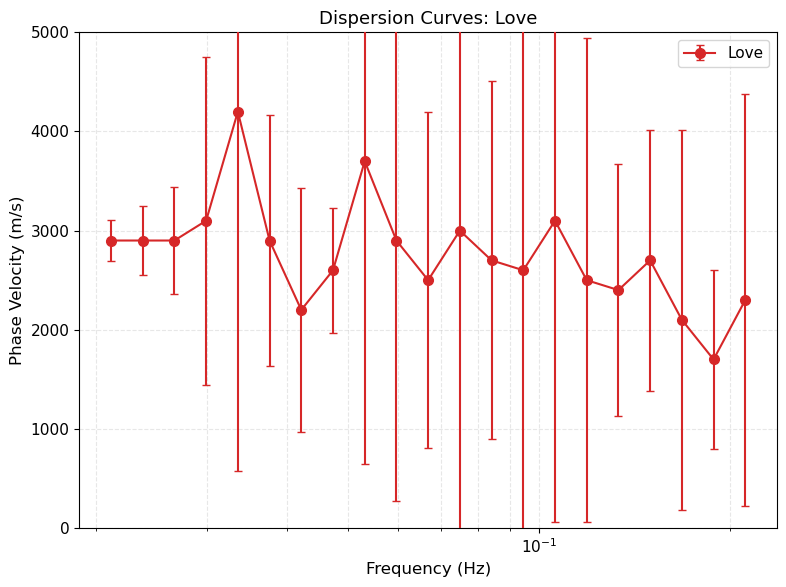

KDE peak velocities (m/s): [2900 2900 2900 3100 4200 2900 2200 2600 3700 2900 2500 3000 2700 2600
 3100 2500 2400 2700 2100 1700 2300]
Theoretical backazimuth (°): 228.5


In [93]:
fig_curves = plot_dispersion_curves(
    dispersion_results=results,
    show_errors=True,
    xlog=True,
)
plt.show()

print("KDE peak velocities (m/s):", np.round(results["velocities"], 0))
print("Theoretical backazimuth (°):", round(sd.baz_theo, 1))

## 9. Summary

If the procedure is correct you should observe:

1. **Adaptive windows:** `T_window = max(window_factor / f_center, 1 s)` for every band.
2. **Overlap:** consecutive windows overlap by `time_window_overlap` (50% here); zoom plot makes this visible.
3. **Alignment:** black window-centre markers coincide with red expected markers; difference plot is ~0.
4. **Counts:** `len(times) == len(velocities) == len(backazimuths)` and matches the sliding-window formula.
5. **Real data:** Love-wave KDE peaks and per-window velocities are physically plausible for this teleseismic event at ROMY.